## Nonlinear Portfolio Transformer: Encoding Variant Comparison

Kelly et al. (2025) encoder-only transformer trained on a single country. A scalar encoding layer before the transformer is the only variable across the six conditions. Set the country code below to match the data processing notebook.

### 1. Setup

In [1]:
import gc
import json
import pickle
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.size'] = 11

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}, device: {device}')
if torch.cuda.is_available(): print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch 2.12.0+cu130, device: cuda
GPU: NVIDIA GeForce RTX 2080 Super with Max-Q Design


### 2. Configuration

In [2]:
# Set this to match your data processing notebook
country = 'IND'

data_dir = Path('../data/processed') / country
results_dir = Path('../results') / country
results_dir.mkdir(parents = True, exist_ok = True)

with open(data_dir / f'{country}_metadata.json') as f: meta = json.load(f)
char_cols = meta['char_cols']
d = meta['d']

firm_lookup = pd.read_parquet(data_dir / f'{country}_firm_lookup.parquet')
id_to_gvkey = dict(zip(firm_lookup['id'], firm_lookup.get('gvkey', firm_lookup['id'])))

n_blocks = 2
n_heads = 1
d_ff = 256
n_epochs = 50
lr = 1e-5
grad_clip = 1.0
n_seeds = 3
patience = 10
rebalance_freq = 6
tc_bps = 25

variant_list = ['identity', 'linear', 'ple', 'periodic', 'fourier', 'magnitude_dir']

print(f'country: {country}, d = {d}')
print(f'firms: {len(firm_lookup):,}')

country: IND, d = 187
firms: 6,267


### 3. Data Loading

In [3]:
def load_split(split):
	p = data_dir / f'{country}_{split}.parquet'
	df = pd.read_parquet(p)
	df['eom'] = pd.to_datetime(df['eom'])
	months = {}
	for eom, g in df.groupby('eom'):
		x = g[char_cols].values.astype(np.float32)
		r = g['ret_exc_lead1m'].values.astype(np.float32)
		ids = g['id'].values
		hr = np.isfinite(r)
		months[eom] = {'x': x, 'r': r, 'has_ret': hr, 'ids': ids}
	return months


def to_gpu(md):
	result = {}
	for eom, m in md.items():
		hr = m['has_ret']
		if hr.sum() < 5: continue
		result[eom] = {
			'x': torch.tensor(m['x'][hr], dtype = torch.float32, device = device),
			'r': torch.tensor(m['r'][hr], dtype = torch.float32, device = device),
			'ids': m['ids'][hr],
		}
	return result


train_months = load_split('train')
val_months = load_split('val')
test_months = load_split('test')

train_gpu = to_gpu(train_months)
val_gpu = to_gpu(val_months)
test_gpu = to_gpu(test_months)

nf = np.mean([m['x'].shape[0] for m in train_gpu.values()])
print(f'train: {len(train_gpu)} months, ~{nf:.0f} firms/month')
print(f'val: {len(val_gpu)} months')
print(f'test: {len(test_gpu)} months')

train: 217 months, ~1163 firms/month
val: 60 months
test: 72 months


### 4. Encoding Variants

In [4]:
class IdentityEncoder(nn.Module):
	def forward(self, x): return x

class LinearEncoder(nn.Module):
	def __init__(self, n):
		super().__init__()
		self.w = nn.Parameter(torch.ones(n))
		self.b = nn.Parameter(torch.zeros(n))
	def forward(self, x): return x * self.w + self.b

class PLEEncoder(nn.Module):
	def __init__(self, n, bins = 16):
		super().__init__()
		bd = torch.linspace(-0.5, 0.5, bins + 1)
		self.register_buffer('lo', bd[:-1])
		self.register_buffer('hi', bd[1:])
		self.w = nn.Parameter(torch.zeros(n, bins))
	def forward(self, x):
		a = torch.clamp((x.unsqueeze(-1) - self.lo) / (self.hi - self.lo + 1e-8), 0, 1)
		return x + (a * self.w.unsqueeze(0)).sum(-1)

class PeriodicEncoder(nn.Module):
	def __init__(self, n, nf = 8):
		super().__init__()
		self.om = nn.Parameter(torch.randn(n, nf))
		self.ph = nn.Parameter(torch.randn(n, nf) * 0.1)
		self.c = nn.Parameter(torch.zeros(n, nf))
	def forward(self, x):
		return x + (torch.sin(x.unsqueeze(-1) * self.om.unsqueeze(0) + self.ph.unsqueeze(0)) * self.c.unsqueeze(0)).sum(-1)

class FourierEncoder(nn.Module):
	def __init__(self, n, nf = 8):
		super().__init__()
		self.register_buffer('freq', torch.arange(1, nf + 1, dtype = torch.float32) * torch.pi)
		self.a = nn.Parameter(torch.zeros(n, nf))
		self.b = nn.Parameter(torch.zeros(n, nf))
	def forward(self, x):
		s = x.unsqueeze(-1) * self.freq
		return x + (torch.sin(s) * self.a.unsqueeze(0) + torch.cos(s) * self.b.unsqueeze(0)).sum(-1)

class MagnitudeDirectionEncoder(nn.Module):
	def __init__(self, n):
		super().__init__()
		self.wp = nn.Parameter(torch.ones(n))
		self.wn = nn.Parameter(torch.ones(n))
		self.b = nn.Parameter(torch.zeros(n))
	def forward(self, x): return F.relu(x) * self.wp - F.relu(-x) * self.wn + self.b

def build_encoder(v, n):
	enc = {'identity': IdentityEncoder, 'linear': LinearEncoder, 'ple': PLEEncoder,
		'periodic': PeriodicEncoder, 'fourier': FourierEncoder, 'magnitude_dir': MagnitudeDirectionEncoder}
	return enc[v]() if v == 'identity' else enc[v](n)

### 5. Kelly Architecture

In [5]:
class AttentionHead(nn.Module):
	def __init__(self, n, s):
		super().__init__()
		self.w = nn.Parameter(torch.randn(n, n) * s)
		self.v = nn.Parameter(torch.randn(n, n) * s)
		self.sc = 1.0 / np.sqrt(n)
	def forward(self, y):
		return F.softmax((y @ self.w @ y.t()) * self.sc, dim = -1) @ (y @ self.v)

class TransformerBlock(nn.Module):
	def __init__(self, n, h, ff, s):
		super().__init__()
		self.heads = nn.ModuleList([AttentionHead(n, s) for _ in range(h)])
		self.w1 = nn.Parameter(torch.randn(n, ff) * (1.0 / ff))
		self.b1 = nn.Parameter(torch.zeros(ff))
		self.w2 = nn.Parameter(torch.randn(ff, n) * s)
		self.b2 = nn.Parameter(torch.zeros(n))
	def forward(self, y):
		y = sum(h(y) for h in self.heads) + y
		return F.relu(y @ self.w1 + self.b1) @ self.w2 + self.b2 + y

class PortfolioTransformer(nn.Module):
	def __init__(self, n, nb, nh, ff, enc):
		super().__init__()
		self.enc = enc
		s = 1.0 / n
		self.blocks = nn.ModuleList([TransformerBlock(n, nh, ff, s) for _ in range(nb)])
		self.lam = nn.Parameter(torch.randn(n) * s)
	def forward(self, x):
		y = self.enc(x)
		for b in self.blocks: y = b(y)
		return y @ self.lam
	def msrr_loss(self, x, r): return (1.0 - self.forward(x) @ r) ** 2

print(f'params: {sum(p.numel() for p in PortfolioTransformer(d, n_blocks, n_heads, d_ff, IdentityEncoder()).parameters()):,}')

params: 332,437


### 6. Training

In [6]:
@torch.no_grad()
def val_rank_corr(model, vg):
	model.eval()
	corrs = []
	for m in vg.values():
		w = model(m['x']).cpu().numpy()
		r = m['r'].cpu().numpy()
		if len(w) < 10: continue
		c, _ = spearmanr(w, r)
		if not np.isnan(c): corrs.append(c)
	model.train()
	return float(np.mean(corrs)) if corrs else 0.0


@torch.no_grad()
def predict_weights(model, mg):
	model.eval()
	wts = {}
	for eom, m in mg.items():
		w = model(m['x']).cpu().numpy()
		wts[eom] = {'w': w, 'ids': m['ids'], 'r': m['r'].cpu().numpy()}
	return wts


def train_one_seed(variant, seed):
	torch.manual_seed(seed)
	np.random.seed(seed)
	model = PortfolioTransformer(d, n_blocks, n_heads, d_ff, build_encoder(variant, d).to(device)).to(device)
	opt = torch.optim.Adam(model.parameters(), lr = lr, weight_decay = 1e-3)
	keys = list(train_gpu.keys())
	nm = len(keys)
	hist = {'loss': [], 'val_corr': []}
	bv = -np.inf
	be = 0
	bs = None
	wait = 0

	for ep in range(1, n_epochs + 1):
		model.train()
		el = 0.0
		for idx in np.random.permutation(nm):
			opt.zero_grad()
			loss = model.msrr_loss(train_gpu[keys[idx]]['x'], train_gpu[keys[idx]]['r'])
			loss.backward()
			nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
			opt.step()
			el += loss.item()
		vc = val_rank_corr(model, val_gpu)
		hist['loss'].append(el / nm)
		hist['val_corr'].append(vc)
		if vc > bv:
			bv = vc
			be = ep
			bs = {k: v.cpu().clone() for k, v in model.state_dict().items()}
			wait = 0
		else: wait += 1
		if wait >= patience: break

	if bs: model.load_state_dict(bs); model = model.to(device)
	return model, hist, be, bv


def train_variant(variant):
	print(f'\nVariant: {variant}')
	vdir = results_dir / variant
	vdir.mkdir(parents = True, exist_ok = True)
	t0 = time.time()

	all_sw = []
	all_h = []
	for seed in range(n_seeds):
		model, hist, be, bv = train_one_seed(variant, seed)
		print(f'  seed {seed}: epoch {be}, val corr {bv:.4f}')
		torch.save(model.state_dict(), vdir / f'{variant}_{country}_seed{seed}.pt')
		all_sw.append(predict_weights(model, {**train_gpu, **val_gpu, **test_gpu}))
		all_h.append(hist)
		del model
		gc.collect()
		torch.cuda.empty_cache()

	# Average
	averaged = {}
	for eom in all_sw[0]:
		ws = np.zeros(len(all_sw[0][eom]['w']))
		sdf_s = 0.0
		nv = 0
		for sw in all_sw:
			w = sw[eom]['w'].astype(np.float64)
			a = np.abs(w).sum()
			if a > 1e-10:
				ws += w / a
				sdf_s += float(w @ sw[eom]['r'].astype(np.float64))
				nv += 1
		if nv > 0:
			averaged[eom] = {'w': (ws / nv).astype(np.float32), 'ids': all_sw[0][eom]['ids'],
				'r': all_sw[0][eom]['r'], 'sdf_ret': sdf_s / nv}

	elapsed = time.time() - t0
	with open(vdir / f'{variant}_{country}_weights.pkl', 'wb') as f: pickle.dump(averaged, f)
	with open(vdir / f'{variant}_{country}_histories.json', 'w') as f: json.dump(all_h, f, default = float)
	print(f'  time: {elapsed / 60:.1f} min')
	return averaged, all_h, elapsed

### 7. Evaluation

In [ ]:
def rank_corr(wts, split_months):
	keys = sorted([k for k in wts if k in split_months])
	corrs = []
	for eom in keys:
		if len(wts[eom]['w']) < 10: continue
		c, _ = spearmanr(wts[eom]['w'], wts[eom]['r'])
		if not np.isnan(c): corrs.append(c)
	return float(np.mean(corrs)) if corrs else 0.0, corrs


def quintile_sim(wts, split_months):
	keys = sorted([k for k in wts if k in split_months])
	if not keys: return np.array([]), []
	rset = set(keys[::rebalance_freq])
	ml = []
	li = set()
	si = set()
	pl = set()
	ps = set()
	hl = []
	for eom in keys:
		m = wts[eom]
		w = m['w']
		r = m['r']
		ids = m['ids']
		tc = 0.0
		if eom in rset:
			nq = max(1, int(len(w) * 0.20))
			so = np.argsort(w)
			li = set(ids[so[::-1][:nq]].tolist())
			si = set(ids[so[:nq]].tolist())
			to = (len(li - pl) + len(pl - li) + len(si - ps) + len(ps - si)) / max(nq, 1)
			tc = to * tc_bps / 10000.0
			pl = li
			ps = si
			hl.append({'eom': str(eom),
				'long': [{'id': i, 'gvkey': id_to_gvkey.get(i, '')} for i in sorted(li)],
				'short': [{'id': i, 'gvkey': id_to_gvkey.get(i, '')} for i in sorted(si)]})
		if not li: continue
		il = ids.tolist()
		lr = r[np.array([i in li for i in il])]
		sr = r[np.array([i in si for i in il])]
		ml.append((float(lr.mean()) if len(lr) > 0 else 0) - (float(sr.mean()) if len(sr) > 0 else 0) - tc)
	return np.array(ml), hl


def score_weighted_sim(wts, split_months):
	keys = sorted([k for k in wts if k in split_months])
	ml = []
	for eom in keys:
		w = wts[eom]['w'].astype(np.float64)
		r = wts[eom]['r'].astype(np.float64)
		ww = w - w.mean()
		a = np.abs(ww).sum()
		if a > 1e-10: ml.append(float((ww / a) @ r))
	return np.array(ml)


def sdf_returns(wts, split_months):
	keys = sorted([k for k in wts if k in split_months])
	return np.array([wts[k]['sdf_ret'] for k in keys if 'sdf_ret' in wts[k]])


def portfolio_metrics(rets, ppy = 12):
	if len(rets) == 0: return {}
	tw = float((1 + rets).prod())
	ann_ret = -1.0 if tw <= 0 else float(tw ** (ppy / len(rets)) - 1)
	av = float(rets.std() * np.sqrt(ppy))
	sr = ann_ret / max(av, 1e-8)
	se = float(np.sqrt((1 + 0.5 * sr ** 2) / len(rets)))
	pk = np.maximum.accumulate(np.cumprod(1 + rets))
	dd = float(((pk - np.cumprod(1 + rets)) / pk).max()) if len(pk) > 0 else 0
	return {'ann_ret': ann_ret, 'ann_vol': av, 'sharpe': sr, 'se_sharpe': se, 'max_dd': dd, 'n_months': len(rets)}


def evaluate_variant(wts, vname, vdir):
	print(f'\n  {vname}')

	vc, _ = rank_corr(wts, val_months)
	tc_val, tc_monthly = rank_corr(wts, test_months)
	print(f'Rank corr  val: {vc:.4f}  test: {tc_val:.4f}')

	qr, holdings = quintile_sim(wts, test_months)
	qm = portfolio_metrics(qr)
	print(f'Quintile sharpe: {qm.get("sharpe", 0):.4f} (se {qm.get("se_sharpe", 0):.4f})  ret: {qm.get("ann_ret", 0) * 100:.2f}%')

	swr = score_weighted_sim(wts, test_months)
	swm = portfolio_metrics(swr)
	print(f'Score wt sharpe: {swm.get("sharpe", 0):.4f} (se {swm.get("se_sharpe", 0):.4f})  ret: {swm.get("ann_ret", 0) * 100:.2f}%')

	sdfr = sdf_returns(wts, test_months)
	sdfm = portfolio_metrics(sdfr)
	print(f'SDF sharpe: {sdfm.get("sharpe", 0):.4f} (se {sdfm.get("se_sharpe", 0):.4f})  ret: {sdfm.get("ann_ret", 0) * 100:.2f}%')

	np.save(vdir / f'{vname}_{country}_quintile.npy', qr)
	np.save(vdir / f'{vname}_{country}_scorewt.npy', swr)
	np.save(vdir / f'{vname}_{country}_sdf.npy', sdfr)
	with open(vdir / f'{vname}_{country}_holdings.json', 'w') as f:
		json.dump(holdings, f, indent = 2, default = str)
	with open(vdir / f'{vname}_{country}_rank_corrs.json', 'w') as f:
		json.dump({'val': vc, 'test': tc_val, 'test_monthly': tc_monthly}, f, default = float)

	return {'variant': vname, 'val_corr': vc, 'test_corr': tc_val,
		'quintile': qm, 'score_weighted': swm, 'sdf': sdfm}

### 8. Per Variant Training

In [8]:
results = {}

In [9]:
wts_identity, hist_identity, time_identity = train_variant('identity')
results['identity'] = evaluate_variant(wts_identity, 'identity', results_dir / 'identity')
results['identity']['time_min'] = time_identity / 60


Variant: identity
  seed 0: epoch 13, val corr 0.0622
  seed 1: epoch 17, val corr 0.0610
  seed 2: epoch 9, val corr 0.0724
  time: 2.2 min

  identity
  Rank corr  val: 0.0706  test: 0.0714
  Quintile   sharpe: 2.4653 (se 0.2368)  ret: 16.61%
  Score wt   sharpe: 4.2975 (se 0.3770)  ret: 12.84%
  SDF        sharpe: 461.6508 (se 38.4711)  ret: 129494.91%


In [10]:
wts_linear, hist_linear, time_linear = train_variant('linear')
results['linear'] = evaluate_variant(wts_linear, 'linear', results_dir / 'linear')
results['linear']['time_min'] = time_linear / 60


Variant: linear
  seed 0: epoch 13, val corr 0.0617
  seed 1: epoch 17, val corr 0.0614
  seed 2: epoch 9, val corr 0.0725
  time: 2.5 min

  linear
  Rank corr  val: 0.0707  test: 0.0715
  Quintile   sharpe: 2.4434 (se 0.2353)  ret: 16.63%
  Score wt   sharpe: 4.3303 (se 0.3796)  ret: 12.92%
  SDF        sharpe: 410.2529 (se 34.1879)  ret: 112474.77%


In [11]:
wts_ple, hist_ple, time_ple = train_variant('ple')
results['ple'] = evaluate_variant(wts_ple, 'ple', results_dir / 'ple')
results['ple']['time_min'] = time_ple / 60


Variant: ple
  seed 0: epoch 8, val corr 0.0601
  seed 1: epoch 17, val corr 0.0581
  seed 2: epoch 7, val corr 0.0712
  time: 2.4 min

  ple
  Rank corr  val: 0.0712  test: 0.0669
  Quintile   sharpe: 2.0174 (se 0.2053)  ret: 15.33%
  Score wt   sharpe: 4.3676 (se 0.3826)  ret: 12.32%
  SDF        sharpe: 389.2325 (se 32.4363)  ret: 98047.15%


In [12]:
wts_periodic, hist_periodic, time_periodic = train_variant('periodic')
results['periodic'] = evaluate_variant(wts_periodic, 'periodic', results_dir / 'periodic')
results['periodic']['time_min'] = time_periodic / 60


Variant: periodic
  seed 0: epoch 13, val corr 0.0626
  seed 1: epoch 5, val corr 0.0642
  seed 2: epoch 10, val corr 0.0635
  time: 2.3 min

  periodic
  Rank corr  val: 0.0712  test: 0.0652
  Quintile   sharpe: 1.4507 (se 0.1688)  ret: 11.25%
  Score wt   sharpe: 3.4264 (se 0.3089)  ret: 10.63%
  SDF        sharpe: 190.9317 (se 15.9114)  ret: 48933.12%


In [13]:
wts_fourier, hist_fourier, time_fourier = train_variant('fourier')
results['fourier'] = evaluate_variant(wts_fourier, 'fourier', results_dir / 'fourier')
results['fourier']['time_min'] = time_fourier / 60


Variant: fourier
  seed 0: epoch 13, val corr 0.0619
  seed 1: epoch 17, val corr 0.0601
  seed 2: epoch 9, val corr 0.0732
  time: 2.6 min

  fourier
  Rank corr  val: 0.0707  test: 0.0729
  Quintile   sharpe: 2.6531 (se 0.2505)  ret: 16.72%
  Score wt   sharpe: 4.2980 (se 0.3771)  ret: 13.00%
  SDF        sharpe: 455.6220 (se 37.9687)  ret: 126922.26%


In [14]:
wts_magnitude_dir, hist_magnitude_dir, time_magnitude_dir = train_variant('magnitude_dir')
results['magnitude_dir'] = evaluate_variant(wts_magnitude_dir, 'magnitude_dir', results_dir / 'magnitude_dir')
results['magnitude_dir']['time_min'] = time_magnitude_dir / 60


Variant: magnitude_dir
  seed 0: epoch 13, val corr 0.0613
  seed 1: epoch 17, val corr 0.0604
  seed 2: epoch 9, val corr 0.0720
  time: 2.6 min

  magnitude_dir
  Rank corr  val: 0.0700  test: 0.0714
  Quintile   sharpe: 2.4598 (se 0.2364)  ret: 16.50%
  Score wt   sharpe: 4.3496 (se 0.3811)  ret: 13.02%
  SDF        sharpe: 428.1003 (se 35.6752)  ret: 118127.98%


### 9. Results

In [ ]:
print(f'Encoding Variant Comparison: {country}')
print(f'{"Variant":<18} {"Corr":>6} {"Q":>7} {"SW":>7} {"SDF":>7} {"Ret":>7} {"Time":>5}')

for v, r in sorted(results.items(), key = lambda x: -x[1]['test_corr']):
	q = r.get('quintile', {})
	sw = r.get('score_weighted', {})
	sd = r.get('sdf', {})
	print(f'{v:<18} {r["test_corr"]:6.4f} {q.get("sharpe", 0):7.3f} '
		f'{sw.get("sharpe", 0):7.3f} {sd.get("sharpe", 0):7.3f} '
		f'{q.get("ann_ret", 0) * 100:6.2f}% {r.get("time_min", 0):4.0f}m')

with open(results_dir / f'{country}_encoding_comparison.json', 'w') as f:
	json.dump(results, f, indent = 2, default = lambda x: float(x) if hasattr(x, '__float__') else str(x))
print(f'\nSaved: {results_dir / f"{country}_encoding_comparison.json"}')

Encoding Variant Comparison: IND

Variant              Corr       Q      SW     SDF     Ret  Time

fourier            0.0729   2.653   4.298 455.622  16.72%    3m
linear             0.0715   2.443   4.330 410.253  16.63%    2m
magnitude_dir      0.0714   2.460   4.350 428.100  16.50%    3m
identity           0.0714   2.465   4.298 461.651  16.61%    2m
ple                0.0669   2.017   4.368 389.232  15.33%    2m
periodic           0.0652   1.451   3.426 190.932  11.25%    2m

Saved: ..\results\IND\IND_encoding_comparison.json


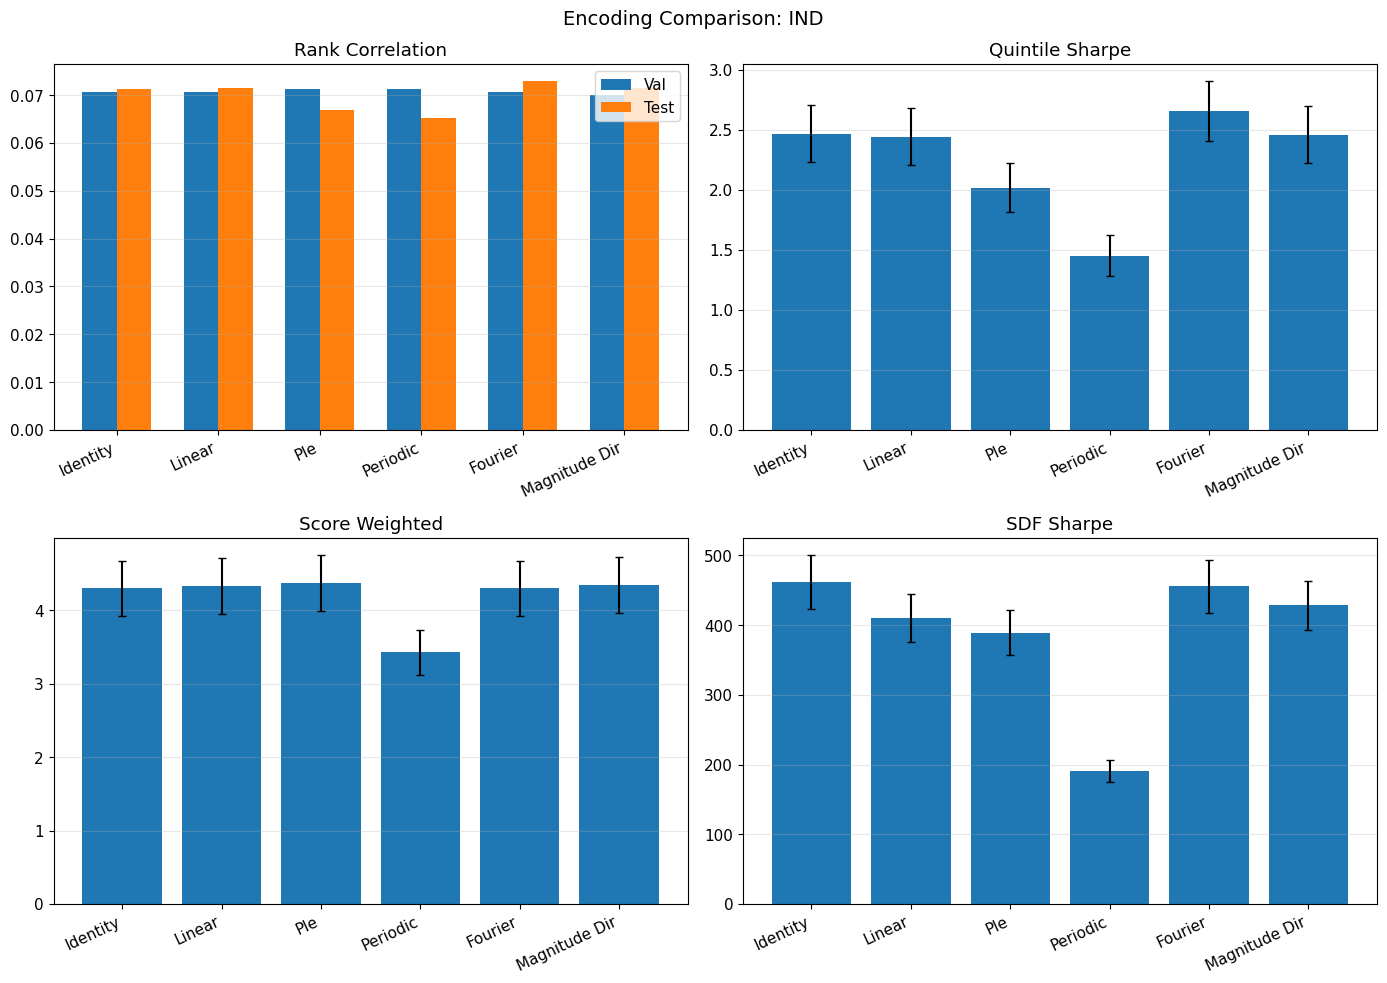

In [16]:
fig, axes = plt.subplots(2, 2, figsize = (14, 10))
fig.suptitle(f'Encoding Comparison: {country}', fontsize = 14)
vs = list(results.keys())
lb = [v.replace('_', ' ').title() for v in vs]
x = np.arange(len(vs))

axes[0,0].bar(x - 0.17, [results[v]['val_corr'] for v in vs], 0.34, label = 'Val')
axes[0,0].bar(x + 0.17, [results[v]['test_corr'] for v in vs], 0.34, label = 'Test')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(lb, rotation = 25, ha = 'right')
axes[0,0].set_title('Rank Correlation')
axes[0,0].legend()
axes[0,0].grid(axis = 'y', alpha = 0.3)

for i, (key, title) in enumerate([('quintile', 'Quintile Sharpe'), ('score_weighted', 'Score Weighted'), ('sdf', 'SDF Sharpe')]):
	ax = axes[(i + 1) // 2, (i + 1) % 2]
	sh = [results[v].get(key, {}).get('sharpe', 0) for v in vs]
	se = [results[v].get(key, {}).get('se_sharpe', 0) for v in vs]
	ax.bar(x, sh, yerr = se, capsize = 3)
	ax.set_xticks(x)
	ax.set_xticklabels(lb, rotation = 25, ha = 'right')
	ax.set_title(title)
	ax.grid(axis = 'y', alpha = 0.3)

plt.tight_layout()
# plt.savefig(results_dir / f'{country}_encoding_comparison.png', dpi = 150, bbox_inches = 'tight')
plt.show()

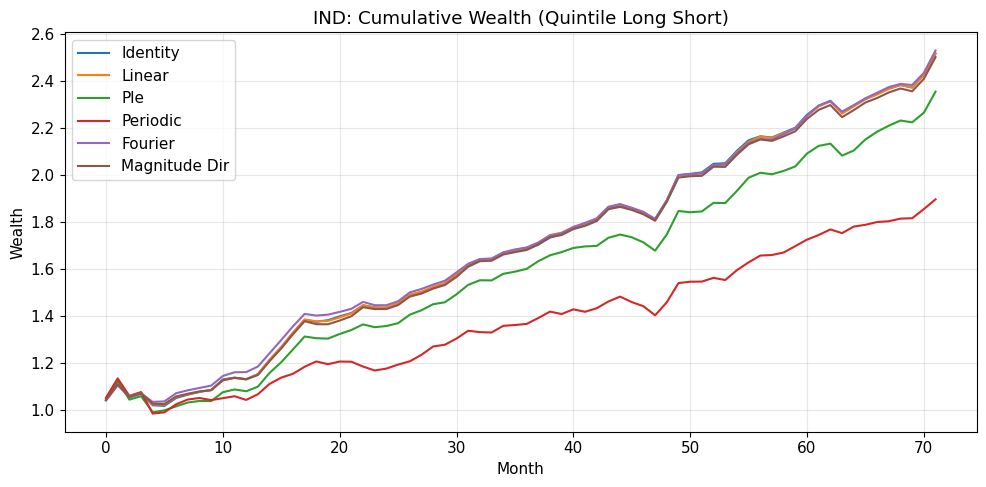

In [17]:
fig, ax = plt.subplots(figsize = (10, 5))
for v in vs:
	p = results_dir / v / f'{v}_{country}_quintile.npy'
	if p.exists():
		ax.plot(np.cumprod(1 + np.load(p)), label = v.replace('_', ' ').title())
ax.set_title(f'{country}: Cumulative Wealth (Quintile Long Short)')
ax.set_xlabel('Month')
ax.set_ylabel('Wealth')
ax.legend()
ax.grid(alpha = 0.3)
plt.tight_layout()
# plt.savefig(results_dir / f'{country}_cumulative_wealth.png', dpi = 150, bbox_inches = 'tight')
plt.show()